In [ ]:
'''
Multivariable Regression

'''

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
CSV_PATH = "student_performance.csv"

In [18]:
df = pd.read_csv(CSV_PATH)
print("First 5 rows:\n", df.head(), "\n")

First 5 rows:
    Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0   



In [19]:
target_candidates = ['G3', 'final_grade', 'FinalGrade', 'score']
target = next((t for t in target_candidates if t in df.columns), df.columns[-1])
print(f"Using target column: {target}\n")


Using target column: Performance Index



In [6]:
X = df.drop(columns=[target])

In [7]:
X = pd.get_dummies(X, drop_first=True)
y = df[target]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [14]:
y_pred = model.predict(X_test)

In [15]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 4.082628398521855
R2: 0.9889832909573145


In [16]:
coefs = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False).head(10)
print("\nTop coefficients:\n", coefs)


Top coefficients:
 Hours Studied                       2.852484
Previous Scores                     1.016988
Extracurricular Activities_Yes      0.608617
Sleep Hours                         0.476941
Sample Question Papers Practiced    0.191831
dtype: float64


In [20]:
sns.set(style="whitegrid", palette="pastel")

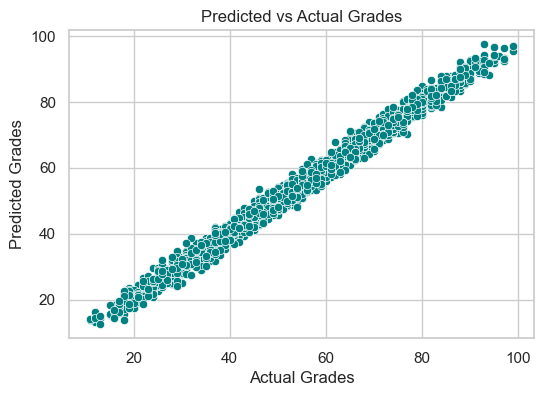

In [21]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=y_pred, color='teal')
plt.title("Predicted vs Actual Grades")
plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


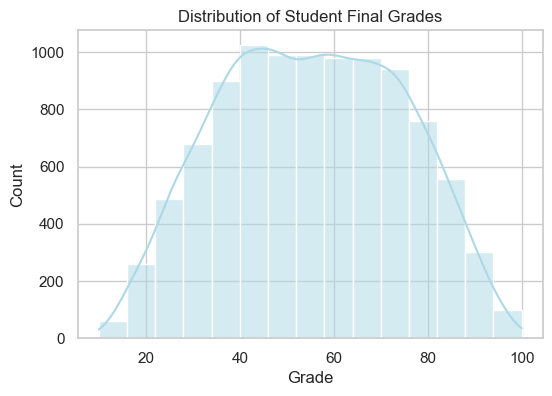

In [22]:
plt.figure(figsize=(6, 4))
sns.histplot(df[target], bins=15, kde=True, color='lightblue')
plt.title("Distribution of Student Final Grades")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.show()

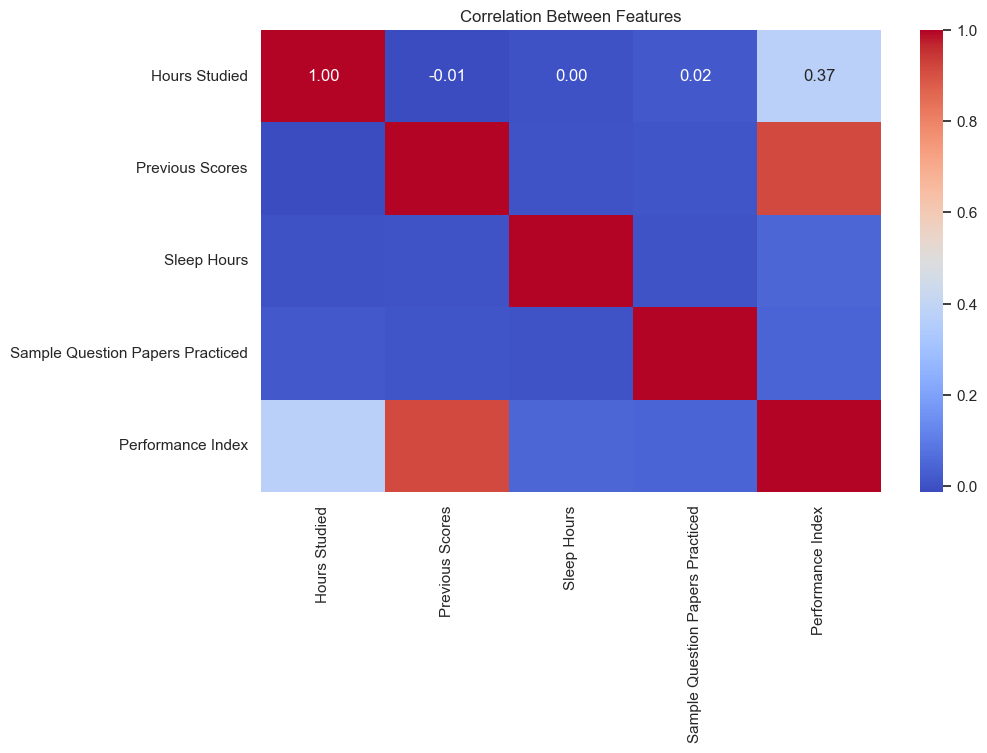

In [23]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Features")
plt.show()